# PINN for RC circuit with physics loss 
### Decomment 2nd block of code for consistent initialising seed
### Network trained with dataset used ***with DataLoader***
### Data are normalised using Min-Max scaler

In [15]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import csv 
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib
import random


In [16]:
# Check Hardware (mps)

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [17]:
# Initialise random seed for model weights and activations

"""def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # If using torch.backends (optional for CPU, more relevant for CUDA)
    if torch.backends.mps.is_available():
        torch.use_deterministic_algorithms(True)

set_seed(42)"""

'def set_seed(seed=42):\n    torch.manual_seed(seed)\n    np.random.seed(seed)\n    random.seed(seed)\n\n    # If using torch.backends (optional for CPU, more relevant for CUDA)\n    if torch.backends.mps.is_available():\n        torch.use_deterministic_algorithms(True)\n\nset_seed(42)'

In [18]:
df = pd.read_csv("rc_transient.csv")
#print(df)
print(df.shape)

df.describe()


"""df = pd.read_csv("rc_transient.csv")

df_sample = df.sample(n=100000, random_state=42)

X = df[["R", "C", "Time", "Vin"]].values
y = df[["Vout"]].values"""

(7911230, 5)


'df = pd.read_csv("rc_transient.csv")\n\ndf_sample = df.sample(n=100000, random_state=42)\n\nX = df[["R", "C", "Time", "Vin"]].values\ny = df[["Vout"]].values'

(500000, 1)


Text(0, 0.5, 'U input')

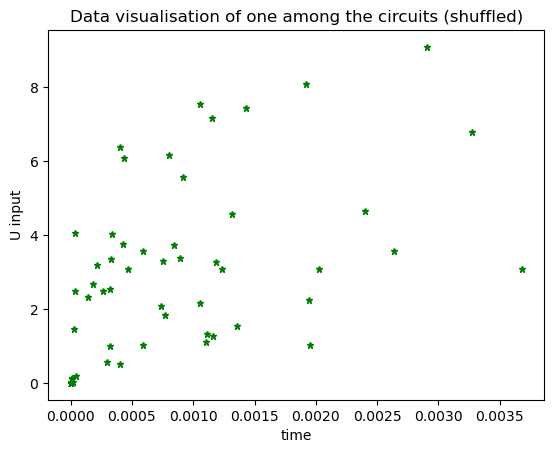

In [19]:

# Data normalisation
test_size = 500000

R = df[["R"]].values[:test_size]
C = df[["C"]].values[:test_size]
t = df[["Time"]].values[:test_size]
Vin = df[["Vin"]].values[:test_size]
Vout = df[["Vout"]].values[:test_size]

# Split into training and test (90% train, 10% test)
R_train, R_test, \
C_train, C_test, \
t_train, t_test, \
Vin_train, Vin_test, \
Vout_train, Vout_test = train_test_split(
    R, C, t, Vin, Vout, test_size=0.1, shuffle=True, random_state=42
)

# Use minmax normalisation for physics problem
scaler_R = MinMaxScaler()
scaler_C = MinMaxScaler()
scaler_t = MinMaxScaler()
scaler_vin = MinMaxScaler()
scaler_vout = MinMaxScaler()

print(R.shape)

# Use float64 for database with small values
R_tensor = torch.tensor(scaler_R.fit_transform(R_train), dtype = torch.float64)
C_tensor = torch.tensor(scaler_C.fit_transform(C_train), dtype = torch.float64)
t_tensor = torch.tensor(scaler_t.fit_transform(t_train), dtype = torch.float64)
Vin_tensor = torch.tensor(scaler_vin.fit_transform(Vin_train), dtype = torch.float64)
Vout_tensor = torch.tensor(scaler_vout.fit_transform(Vout_train), dtype = torch.float64)


#print(X_tensor[:,0])
#print(Y_tensor)


X_tensor = torch.cat([R_tensor, C_tensor, t_tensor, Vin_tensor], dim = 1)

dataset = TensorDataset(X_tensor, Vout_tensor)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

plt.title("Data visualisation of one among the circuits (shuffled)")
plt.plot(t_train[:72], Vout_train[:72], linestyle='None', color='green', marker='*', markersize=5)
plt.xlabel("time")
plt.ylabel("U input")




In [20]:
nb_neu = 128
nb_neu2 = 128

class RegressionModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, nb_neu)
        self.fc2 = nn.Linear(nb_neu,nb_neu2)
        self.fc3 = nn.Linear(nb_neu, out_features)
        

    
    def forward(self, r, c, t, v):
        inp_combined = torch.cat([r, c, t, v], dim = 1)
        x = F.silu(self.fc1(inp_combined))  # silu/Swish activation for complex problem
        x = F.silu(self.fc2(x))
        x = (self.fc3(x))  # No activation on output for regression
        return x

In [21]:
in_features = 4
out_features = 1


model = RegressionModel(in_features=4, out_features=1).double()


criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)


## The differential equation that controls our physics loss 

## ⚙️ Differential Equation of an RC Circuit (Time Domain)

The first-order differential equation for the voltage across a capacitor in an RC circuit is:

$$
u(t) + RC \cdot \frac{du(t)}{dt} = U
$$

Where:
- \( u(t) \) is the output voltage (e.g. across the capacitor),
- \( R \) is the resistance (Ω),
- \( C \) is the capacitance (F),
- \( U \) is the constant input voltage.

This equation describes the dynamic response of the voltage in the circuit over time.


In [22]:
# Function to compute the PDE residual: 
def pde_residual(model, R, C, t, Vin):
    # Make sure t requires grad for autograd
    t = t.clone().detach().requires_grad_(True)
    
    # Predict V_out from the model
    V_out_pred = model(R, C, t, Vin)  # shape: [batch_size, 1]
    
    # Compute dV_out/dt (autograd gradient)
    dV_out_dt = torch.autograd.grad(
        outputs=V_out_pred,
        inputs=t,
        grad_outputs=torch.ones_like(V_out_pred),
        create_graph=True
    )[0]  # shape: [batch_size, 1]
    
    # Calculate residual
    residual = R * C * dV_out_dt + V_out_pred - Vin  # all shape: [batch_size, 1]
    
    # Flatten residual to [batch_size] for loss calculation
    return residual.view(-1)



pde_test = pde_residual(model, R_tensor, C_tensor, t_tensor, Vin_tensor)
print("pde dimension: " , pde_test.shape)
print(pde_test)

#pde_residual(model, X_tensor)

pde dimension:  torch.Size([450000])
tensor([-0.2400, -0.5620, -0.6731,  ..., -0.1212, -1.0235, -0.8604],
       dtype=torch.float64, grad_fn=<ViewBackward0>)


Epoch [1], Loss: 0.011659495
Epoch [2], Loss: 0.009453916
Epoch [3], Loss: 0.007376767
Epoch [4], Loss: 0.006376178
Epoch [5], Loss: 0.007986128
Epoch [6], Loss: 0.006435231
Epoch [7], Loss: 0.004366073
Epoch [8], Loss: 0.003237992
Epoch [9], Loss: 0.003080120
Epoch [10], Loss: 0.002505948
Epoch [11], Loss: 0.001721649
Epoch [12], Loss: 0.001611646
Epoch [13], Loss: 0.001584709
Epoch [14], Loss: 0.001406204
Epoch [15], Loss: 0.001703304
Epoch [16], Loss: 0.001435051
Epoch [17], Loss: 0.001365261
Epoch [18], Loss: 0.001565019
Epoch [19], Loss: 0.001687510
Epoch [20], Loss: 0.001105893
Epoch [21], Loss: 0.001050212
Epoch [22], Loss: 0.001301258
Epoch [23], Loss: 0.001107889
Epoch [24], Loss: 0.001002572
Epoch [25], Loss: 0.001021220
Epoch [26], Loss: 0.000840466
Epoch [27], Loss: 0.000929270
Epoch [28], Loss: 0.000776910
Epoch [29], Loss: 0.000925193
Epoch [30], Loss: 0.000882338
Epoch [31], Loss: 0.000891878
Epoch [32], Loss: 0.000810757
Epoch [33], Loss: 0.000726464
Epoch [34], Loss: 0

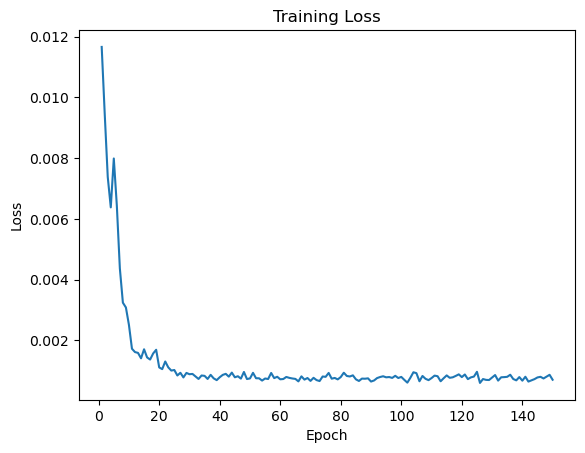

In [23]:
nb_epochs = 150
losses = []
epoch = [] 
# Before training
#set_seed(42)
model.train()
for i in range(nb_epochs):
    for X_batch, y_batch in dataloader:

        # Seperate arguments for gradient in physics loss
        R_batch = X_batch[:,0:1]
        C_batch = X_batch[:,1:2]
        t_batch = X_batch[:,2:3]
        Vin_batch = X_batch[:,3:4]

        # Physics loss
        res = pde_residual(model, R_batch, C_batch, t_batch, Vin_batch)
        loss_physics = torch.mean(res**2)

        # MSE loss
        outputs = model(R_batch, C_batch, t_batch, Vin_batch)
        loss_mse = criterion(outputs, y_batch) 

        # final loss
        lamb = 0.01         # lambda to control influence of physical loss (PDE residual)
        lambmse = 0.99      # lambdamse to control influence of MSE
        
        loss = loss_mse * lambmse + loss_physics * lamb 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses.append(loss.item())
    epoch.append(i+1)
    print(f'Epoch [{i+1}], Loss: {loss.item():.9f}')

# Plot the loss curve
plt.plot(epoch, losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()
   

In [24]:
model.eval()

# No gradient calculation during evaluation
with torch.no_grad():
    # Forward pass
    predictions = model(R_tensor, C_tensor, t_tensor, Vin_tensor)  

    # Calculate the loss (optional)
    loss = criterion(predictions, Vout_tensor)
    print(f"Evaluation Loss: {loss.item():.3f}")

    predictions_original = scaler_vout.inverse_transform(predictions.numpy())


    # Print the inverse transformed predictions
    print("Inverse Predictions: \n", predictions_original)

Evaluation Loss: 0.000
Inverse Predictions: 
 [[-0.00948942]
 [ 4.63610192]
 [ 0.17709294]
 ...
 [ 0.35507914]
 [-0.04067751]
 [-0.05277383]]


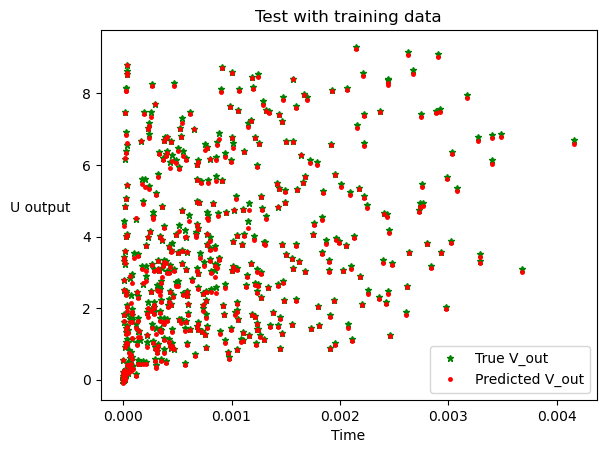

In [25]:
plt.title("Test with training data")
plt.plot(t_train[:720], Vout_train[:720], label = "True V_out", linestyle='None', color='green', marker='*', markersize=5)
plt.xlabel("Time")
plt.ylabel("U output", rotation = 0, labelpad=30)
plt.plot(t_train[:720].flatten(), predictions_original[:720].flatten(), label = "Predicted V_out",linestyle='None', color='red', marker='.', markersize=5)
plt.legend()

plt.show()

In [26]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

# Print optimizer's state_dict
"""print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])"""



Model's state_dict:
fc1.weight 	 torch.Size([128, 4])
fc1.bias 	 torch.Size([128])
fc2.weight 	 torch.Size([128, 128])
fc2.bias 	 torch.Size([128])
fc3.weight 	 torch.Size([1, 128])
fc3.bias 	 torch.Size([1])


'print("Optimizer\'s state_dict:")\nfor var_name in optimizer.state_dict():\n    print(var_name, "\t", optimizer.state_dict()[var_name])'

Evaluation Loss: 0.000


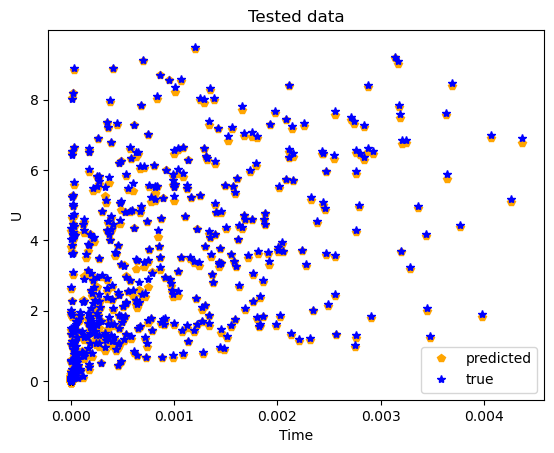

In [27]:
# Defining model name and save the model 
# Also save the data scalers for further evaluations

name = "My_model"    # À changer selon l'utilisateur
torch.save(model.state_dict(), name)

joblib.dump(scaler_R, 'scaler_R.pkl')
joblib.dump(scaler_C, 'scaler_C.pkl')
joblib.dump(scaler_t, 'scaler_t.pkl')
joblib.dump(scaler_vin, 'scaler_vin.pkl')
joblib.dump(scaler_vout, 'scaler_vout.pkl')

# Load the saved model and evaluate

my_model = RegressionModel(in_features, out_features).double()
my_model.load_state_dict(torch.load(name, weights_only=True))
my_model.eval()


# Load new data 

R_tensor2 = torch.tensor(scaler_R.transform(R_test), dtype = torch.float64)
C_tensor2 = torch.tensor(scaler_C.transform(C_test), dtype = torch.float64)
t_tensor2 = torch.tensor(scaler_t.transform(t_test), dtype = torch.float64)
Vin_tensor2 = torch.tensor(scaler_vin.transform(Vin_test), dtype = torch.float64)
y_tensor2 = torch.tensor(scaler_vout.transform(Vout_test), dtype = torch.float64)


with torch.no_grad():
    # Forward pass
    pred2 = my_model(R_tensor2, C_tensor2, t_tensor2, Vin_tensor2)  

    

    # Calculate the loss (optional)
    loss = criterion(pred2, y_tensor2)
    print(f"Evaluation Loss: {loss.item():.3f}")

    # Inverse transform predictions
    pred2_ori = scaler_vout.inverse_transform(pred2.numpy())
    # Print the inverse transformed predictions
    #print("Inverse Predictions: \n", pred2_ori)

# Plot the tested data
plt.title("Tested data")
plt.xlabel("Time")
plt.ylabel("U")
plt.plot(t_test[:720], pred2_ori[:720], label = 'predicted', marker = 'p', linestyle = 'None', color = 'orange')
plt.plot(t_test[:720], Vout_test[:720], label = 'true', color = 'blue', marker = '*', linestyle = 'None')
plt.legend()

#print(pred2)

### Plotting curve with shuffled data will not give us clear report about model's performance.
### Therefore, corelation graph is necessary.

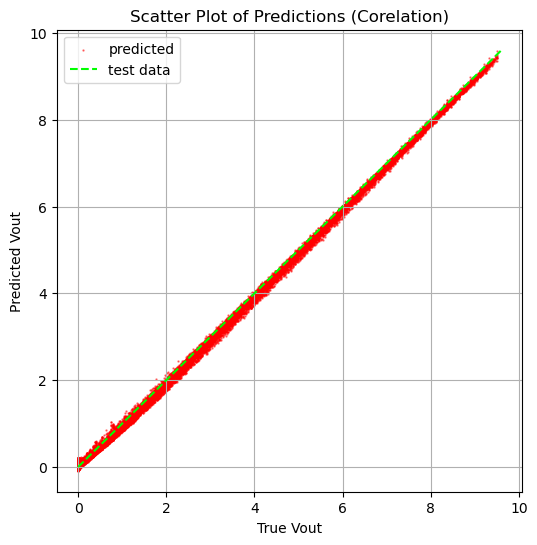

In [28]:
# Data are shuffled so plotting physics curve will give random scatter points
# Corelation graph will give direct report on the model's performance


# Corelation graph 

plt.figure(figsize=(6, 6))
plt.scatter(Vout_test, pred2_ori, alpha=0.5, label = "predicted", color = 'red', s=0.5)
plt.plot([Vout_test.min(), pred2_ori.max()], [Vout_test.min(), pred2_ori.max()], '--', label = "test data", color = 'lime')  # Perfect line
plt.xlabel("True Vout")
plt.ylabel("Predicted Vout")
plt.title("Scatter Plot of Predictions (Corelation)")
plt.legend()
plt.grid(True)
plt.show()